Usamos la libreria pandas y usamos los datos "housing.csv"

In [1]:
import pandas as pd

datos = pd.read_csv("housing.csv")

vemos los primeros 5 datos con .head

In [2]:
datos.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


usamos seaborn para mostrar el valor medio de las casas en cada ubicación con una grafica



<Axes: xlabel='latitude', ylabel='longitude'>

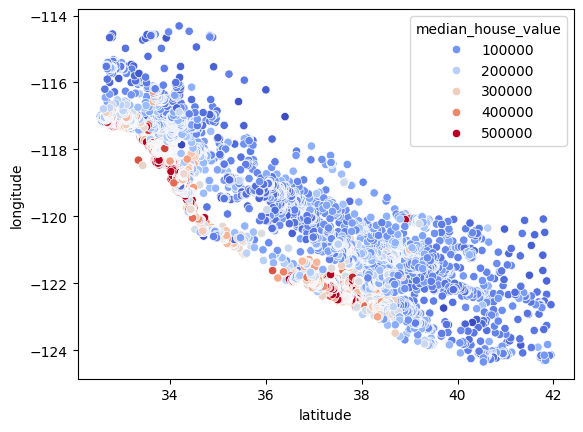

In [7]:
import seaborn as sb
sb.scatterplot(x="latitude",y="longitude",data= datos, hue="median_house_value", palette = "coolwarm")

aqui estámos duplicando la misma variable en dos dimensiones visuales (color y tamaño)

TypeError: cannot convert the series to <class 'float'>

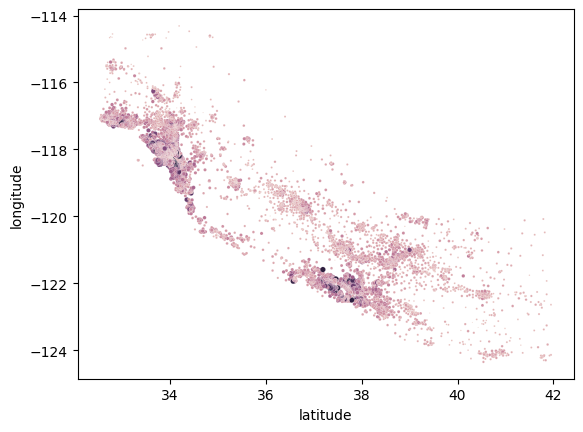

In [10]:
import seaborn as sb
sb.scatterplot(x="latitude",y="longitude",data= datos, hue="median_income", s=datos["median_income"])

vemos los datos de la latitude, longitud y median income

In [12]:
datos.loc[:,['latitude','longitude','median_income']]

,latitude,longitude,median_income
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462
...,...,...,...
20635,39.48,-121.09,1.5603
20636,39.49,-121.21,2.5568
20637,39.43,-121.22,1.7000
20638,39.43,-121.32,1.8672


Este código usa el algoritmo de clustering K-means clustering de la librería scikit-learn para agrupar nuestros datos

In [13]:
from sklearn.cluster import KMeans

x=datos.loc[:,['latitude','longitude','median_income']]
modelo = KMeans(n_clusters=3)
predicciones = modelo.fit_predict(x)

nos da la dimensiones de los datos

In [15]:
predicciones.shape

(20640,)

Toma el resultado del clustering y los guardia en una nueva columna

In [16]:
x["segmento_economico"] = predicciones

muestra los datos

In [17]:
x

,latitude,longitude,median_income,segmento_economico
0,37.88,-122.23,8.3252,1
1,37.86,-122.22,8.3014,1
2,37.85,-122.24,7.2574,1
3,37.85,-122.25,5.6431,1
4,37.85,-122.25,3.8462,1
...,...,...,...,...
20635,39.48,-121.09,1.5603,1
20636,39.49,-121.21,2.5568,1
20637,39.43,-121.22,1.7000,1
20638,39.43,-121.32,1.8672,1


In [18]:
x["segmento_economico"].value_counts()

,count
segmento_economico,
2,9393
1,8457
0,2790


creamos una grafica los nuevos datos

<Axes: xlabel='latitude', ylabel='longitude'>

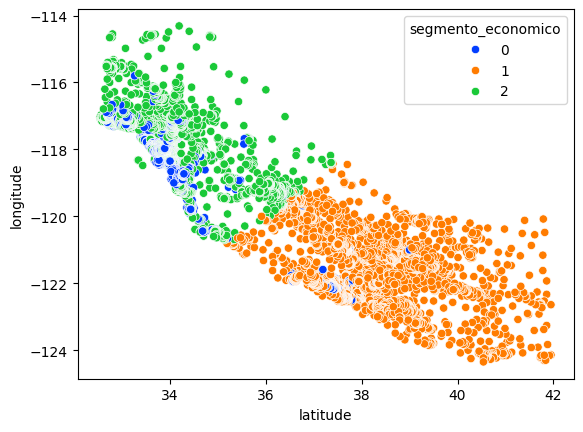

In [22]:
import seaborn as sb
sb.scatterplot(x="latitude",y="longitude",data= x, hue="segmento_economico", palette = "bright")

ahora vemos los datos en una grafica de barras

<Axes: xlabel='segmento_economico', ylabel='count'>

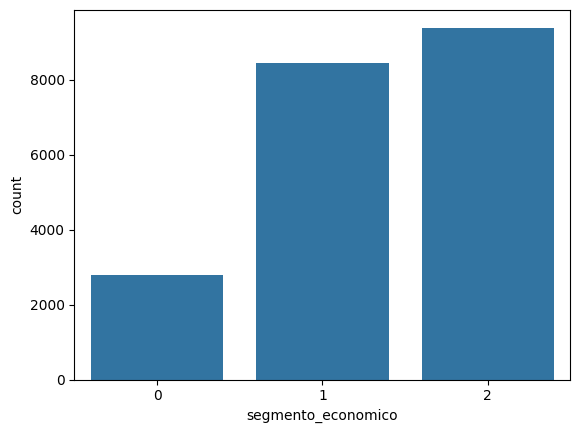

In [23]:
sb.countplot(x="segmento_economico",data= x)

vemos la media de los datos en cada segmento

In [24]:
x.groupby(['segmento_economico'])['median_income'].mean()

,median_income
segmento_economico,
0,6.939482
1,3.681544
2,3.129423
